In [1]:
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'matplotlib', 
                'seaborn', 'sqlalchemy'])

print("Cài đặt hoàn tất!")

Cài đặt hoàn tất!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3  

plt.style.use('seaborn')
print("Import thành công!")

Import thành công!


In [5]:
# Đọc CSV và nạp vào Database SQL
# Đọc file CSV
df = pd.read_csv('C:/Users/PC/fintech-transaction-analysis/data/creditcard.csv')
print("Shape", df.shape)
print(df.head())

# Tạo database SQLite
conn = sqlite3.connect('C:/Users/PC/fintech-transaction-analysis/data/fintech.db')

# Nạp data vào data base
df.to_sql('transactions', conn,
         if_exists='replace',
         index=False)

print("\nĐã tạo database thành công!")
print("Bảng 'transactions' đã sẵn sàng để querry!")

Shape (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26  

# SQL Bài 1: SELECT cơ bản

In [9]:
# CÂU HỎI 1: Data trông như thế nào?

query = """
SELECT *
FROM transactions
LIMIT 10
"""

result = pd.read_sql_query(query, conn)
print(result)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   
5   2.0 -0.425966  0.960523  1.141109 -0.168252  0.420987 -0.029728  0.476201   
6   4.0  1.229658  0.141004  0.045371  1.202613  0.191881  0.272708 -0.005159   
7   7.0 -0.644269  1.417964  1.074380 -0.492199  0.948934  0.428118  1.120631   
8   7.0 -0.894286  0.286157 -0.113192 -0.271526  2.669599  3.721818  0.370145   
9   9.0 -0.338262  1.119593  1.044367 -0.222187  0.499361 -0.246761  0.651583   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -

# SQL Bài 2: Đếm tổng giao dịch

In [35]:
# Câu 2: Có bao nhiêu giao dịch tổng cộng?

query = """
SELECT COUNT(*) as tong_giao_dich
FROM transactions
"""

result = pd.read_sql_query(query, conn)
print(result)

# Nhận xét:
#1. Tổng số giao dịch: 284,807, đây là khối lượng dữ liệu lớn đủ để phân tích có ý nghĩa thống kê. Trong thực tế ngân hàng, con số này có thể lên đến hàng triệu giao dịch/ngày

#2. Ý nghĩa của COUNT trong thực tế: COUNT là câu lệnh DA dùng đâu tiên khi nhận bất kỳ dataset mới nào, giúp biết ngay quy mô dữ liệu trước khi đi vào phân tích chi tiết. Nếu COUNT trả về số quá nhỏ (<1000) thì ta sẽ cần thu thập thêm data trước khi phân tích

   tong_giao_dich
0          284807


# SQL Bài 3: GROUP BY

In [36]:
# Câu hỏi 3: Bao nhiêu giao dịch gian lận vs bình thường?

query = """
SELECT
    Class as loai_giao_dich,
    COUNT(*) as so_luong,
    ROUND(AVG(Amount),2) as so_tien_trung_binh
FROM transactions
GROUP BY Class
"""

result = pd.read_sql_query(query,conn)

# Đổi tên
result['loai_giao_dich'] = result['loai_giao_dich'].map({
    0: 'Bình thường',
    1: 'Gian lận'
})

print(result)

# Nhận xét:
#1. Tổng số giao dịch: Bình thường (284,315 giao dịch ~99.83%) và gian lận (492 giao dịch ~0.17%)
# -> Dataset mất cân bằng nghiêm trọng

#2. So sánh số tiền trung bình: Gian lận ($122.21) cao hơn bình thường ($88.29) khoảng 38%
# -> Kẻ gian lận có xu hướng chọn số tiền vừa phải, không quá nhỏ cũng không quá lớn để tránh bị phát hiện

# Đề xuất: Không nên chỉ dựa vào số lượng để đánh giá gian lận, 492 giao dịch tuy ít nhưng với số tiền trung bình là $122.21 thì thiệt hại ước tính = 492x $122.21 = ~$60,127

  loai_giao_dich  so_luong  so_tien_trung_binh
0    Bình thường    284315               88.29
1       Gian lận       492              122.21


# SQL Bài 4: Vẽ biểu đồ từ kết quả SQL

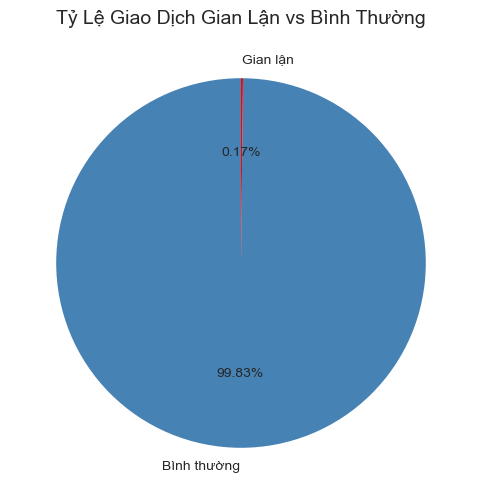

In [21]:
# VISUALIZE: Tỷ lệ giao dịch gian lận

plt.figure(figsize=(8, 6))
plt.pie(
    result['so_luong'],
    labels=result['loai_giao_dich'],
    autopct='%1.2f%%',
    colors=['steelblue', 'red'],
    startangle=90
)
plt.title('Tỷ Lệ Giao Dịch Gian Lận vs Bình Thường', fontsize=14)
plt.savefig('C:/Users/PC/fintech-transaction-analysis/data/bieu_do_1.png')
plt.show()

# Nhận xét biểu đồ 1:
#1. Giao dịch bình thường chiếm 99.83%, gian lận chỉ có 0.17% dẫn đến việc Dataset cực kỳ mất cân bằng

#2. Dù có tỷ lệ rất nhỏ nhưng vẫn có 492 giao dịch gian lận với số tiền trung bình là $122.21, dẫn đến thiệt hại tổng cộng là ~$60,127

# Đề xuất: Hệ thống phát hiện gian lận không thể chỉ dựa vào tỷ lệ, cần tập trung vào các đặc điểm của giao dịch gian lận thay vì số lượng

# SQL Bài 5: Phân tích số tiền giao dịch

In [ ]:
# Câu hỏi 5: Phân bố số tiền giao dịch gian lận?

query = """
SELECT
    Class as loai_giao_dich,
    ROUND(MIN(Amount), 2) as so_tien_nho_nhat,
    ROUND(MAX(Amount), 2) as so_tien_lon_nhat,
    ROUND(AVG(Amount), 2) as so_tien_trung_binh,
    COUNT(*) as so_luon
FROM transactions
GROUP BY Class
"""

result2 = pd.read_sql_query(query, conn)
result2['loai_giao_dich'] = result2['loai_giao_dich'].map({
    0: 'Bình thường',
    1: 'Gian lận'
})
print(result2)

# VISUALIZE: So sánh số tiền giao dịch

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Biểu đồ trái (So sánh số tiền trung bình)
axes[0].bar(
    result2['loai_giao_dich'],
    result2['so_tien_trung_binh'],
    color=['steelblue', 'red']
)
axes[0].set_title('So sánh số tiền trung bình', fontsize=13)
axes[0].set_xlabel('Loại giao dịch')
axes[0].set_ylabel('Số tiền (USD)')

# Thêm số liệu lên từng cột
for i, v in enumerate(result2['so_tien_trung_binh']):
    axes[0].text(i, v + 1, f'${v}', ha='center', fontweight='bold')

# Biểu đồ phải (So sánh số tiền tối đa)
axes[1].bar(
    result2['loai_giao_dich'],
    result2['so_tien_lon_nhat'],
    color=['steelblue', 'red']
)
axes[1].set_title('So sánh số tiền tối đa', fontsize=13)
axes[1].set_xlabel('Loại giao dịch')
axes[1].set_ylabel('Số tiền (USD)')

# Thêm số liệu lên từng cột
for i, v in enumerate(result2['so_tien_lon_nhat']):
    axes[1].text(i, v + 1, f'${v}', ha='center', fontweight='bold')

plt.suptitle('Phân tích số tiền giao dịch', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/PC/fintech-transaction-analysis/data/bieu_do_2.png')
plt.show()

# Nhận xét:
#1. Giao dịch bình thường có số tiền tối đa $25,691 trong khi gian lận tối đa chỉ $2,125
# -> Kẻ gian lận KHÔNG thực hiện giao dịch số tiền quá lớn, có thể cố tình để tránh bị phát hiện

#2. Cả 2 loại đều có giao dịch 0$, cần điều tra thêm các giao dịch 0$ này

#3. Số tiền trung bình gian lận là $122.21, cao hơn bình thường là $88.29
# -> Gian lận tập trung vào mức trung bình, không quá nhỏ cũng không quá lớn, đây là dấu hiệu cố tình che giấu

# Đề xuất: Ngân hàng nên tập trung giám sát các giao dịch trong khoảng $50 - $2,000 thay vì chủ chặn các giao dịch có giá trị lớn

# Nhận xét biểu đồ:
# Biểu đồ trái (Số tiền trung bình): Gian lận ($122.21) cao hơn bình thường ($88.29)
# -> Kẻ gian lận chọn số tiền vừa phải, không quá lớn cũng không quá nhỏ

# Biểu đồ phải (Số tiền tối đa): Bình thường tối đa $25,691 cao hơn rất nhiều so với gian lận tối đa $2,125
# -> Kẻ gian lận cố tình tránh giao dịch lớn để không bị phát hiện

# Đề xuất: Tập tring giám sát giao dịch $100-$2,000 thay vì chỉ chặn giao dịch có giao dịch lớn

# SQL Bài 6 - WHERE: Điều tra giao dịch $0

In [34]:
# CÂU HỎI 6: Giao dịch $0 là gì? Có đáng ngờ không?

query = """
SELECT 
    Class as loai_giao_dich,
    COUNT(*) as so_luong,
    ROUND(AVG(Amount), 2) as so_tien_trung_binh
FROM transactions
WHERE Amount = 0
GROUP BY Class
"""

result3 = pd.read_sql_query(query, conn)
result3['loai_giao_dich'] = result3['loai_giao_dich'].map({
    0: 'Bình thường',
    1: 'Gian lận'
})
print(result3)
print("""
""")

# Nhận xét:
#1. Có 27 giao dịch gian lận với số tiền $0 trên tổng số 1,798 giao dịch $0
# -> Tỷ lệ gian lận trong nhóm $0 = 27/1825 = 1.48%, cao hơn gần 9 lần so với tỷ lệ gian lận chung (0.17%)

#2. Điều này xác nhận giả thuyết: Kẻ gian lận cố tình thực hiện giao dịch $0 để test xem thẻ có hoạt động không trước khi thực hiện giao dịch lớn hơn

# Đề xuất: Ngân hàng không nên bỏ qua giao dịch $0, cần đặt cảnh báo tự động khi phát hiện giao dịch $0 liên tiếp từ cùng 1 tài khoản

  loai_giao_dich  so_luong  so_tien_trung_binh
0    Bình thường      1798                 0.0
1       Gian lận        27                 0.0




# SQL Bài 7 - CASE WHEN: Phân loại mức độ rủi ro

In [30]:
# Câu hỏi 7: Phân loại giao dịch theo mức độ rủi ro

query = """
SELECT 
    CASE 
        WHEN Amount = 0 THEN 'Nghi ngờ - $0'
        WHEN Amount < 50 THEN 'Rủi ro thấp'
        WHEN Amount BETWEEN 50 AND 500 THEN 'Rủi ro trung bình'
        WHEN Amount BETWEEN 500 AND 2000 THEN 'Rủi ro cao'
        ELSE 'Rủi ro rất cao'
    END as muc_do_rui_ro,
    COUNT(*) as tong_giao_dich,
    SUM(CASE WHEN Class = 1 THEN 1 ELSE 0 END) as so_gian_lan,
    ROUND(
        SUM(CASE WHEN Class = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 
        4
    ) as ti_le_gian_lan_pct
FROM transactions
GROUP BY muc_do_rui_ro
ORDER BY ti_le_gian_lan_pct DESC
"""

result4 = pd.read_sql_query(query, conn)
print(result4)

# Nhận xét:
#1. Giao dịch $0 có tỷ lệ gian lận cao nhất = 1.4795%, cao hơn gấp 10 lần mức trung bình (0.17%)
# -> Xác nhận đây là hành vi test thẻ trước khi tấn công

#2. Rủi ro cao ($500-$2000) đứng thứ 2 với 0.4016%
# -> Kẻ gian lận tập trung vào giao dịch có số tiền lớn sau khi đã test thẻ thành công

#3. Rủi ro rất cao (>$2000) lại có tỷ lệ gian lận thấp nhất
# -> Kẻ gian lận tránh giao dịch quá lớn để không bị phát hiện

# Đề xuất: Ngân hàng nên ưu tiên giám sát 2 nhóm: Giao dịch $0 và giao dịch $500-$2000

       muc_do_rui_ro  tong_giao_dich  so_gian_lan  ti_le_gian_lan_pct
0      Nghi ngờ - $0            1825           27              1.4795
1         Rủi ro cao            8466           34              0.4016
2  Rủi ro trung bình           85961          152              0.1768
3        Rủi ro thấp          187879          278              0.1480
4     Rủi ro rất cao             676            1              0.1479


# Vẽ biểu đồ cho Bài 7

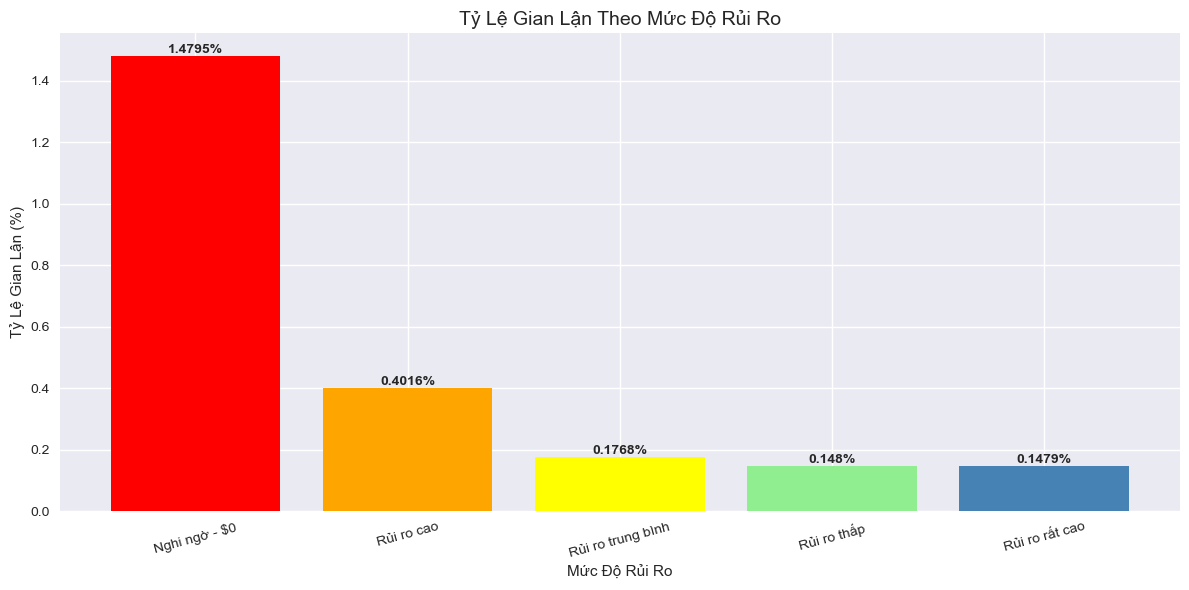

In [33]:
# VISUALIZE: Tỷ lệ gian lận theo mức độ rủi ro

plt.figure(figsize=(12, 6))
bars = plt.bar(
    result4['muc_do_rui_ro'],
    result4['ti_le_gian_lan_pct'],
    color=['red', 'orange', 'yellow', 'lightgreen', 'steelblue']
)

# Thêm số liệu lên từng cột
for bar, val in zip(bars, result4['ti_le_gian_lan_pct']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val}%',
        ha='center',
        fontweight='bold'
    )

plt.title('Tỷ Lệ Gian Lận Theo Mức Độ Rủi Ro', fontsize=14)
plt.xlabel('Mức Độ Rủi Ro')
plt.ylabel('Tỷ Lệ Gian Lận (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('C:/Users/PC/fintech-transaction-analysis/data/bieu_do_3.png')
plt.show()
print("""
""")

# Kết luận, tổng hợp và đề xuất

In [45]:
# Kết luận, tổng hợp và đề xuất

print("""

         PHÂN TÍCH GIAO DỊCH TÀI CHÍNH - FINTECH            
                   KẾT LUẬN TỔNG HỢP                         



 TỔNG QUAN DỮ LIỆU

 → Tổng số giao dịch phân tích : 284,807
 → Giao dịch bình thường       : 284,315 (99.83%)
 → Giao dịch gian lận          : 492     (0.17%)
 → Dataset cực kỳ mất cân bằng 


 INSIGHT 1: ĐẶC ĐIỂM SỐ TIỀN GIAO DỊCH

 → Số tiền TB gian lận ($122.21) cao hơn bình thường ($88.29)
 → Giao dịch gian lận tối đa chỉ $2,125, thấp hơn nhiều so với giao dịch bình thường tối đa $25,691
 → Kẻ gian lận cố tình tránh giao dịch số tiền quá lớn để không bị hệ thống phát hiện


 INSIGHT 2: PHÁT HIỆN HÀNH VI TEST THẺ

 → 27/492 giao dịch gian lận có số tiền = $0
 → Tỷ lệ gian lận trong nhóm $0 = 1.48% cao hơn 9 lần mức trung bình (0.17%)
 → Đây là hành vi test thẻ, kẻ gian lận thực hiện giao dịch $0 để kiểm tra thẻ trước khi tấn công thật


 INSIGHT 3: PHÂN LOẠI RỦI RO THEO MỨC TIỀN

 → Nghi ngờ $0      : tỷ lệ gian lận 1.4795% — Cao nhất
 → Rủi ro cao       : tỷ lệ gian lận 0.4016% — Đứng thứ 2
 → Rủi ro rất cao   : tỷ lệ gian lận 0.1479% — Thấp nhất
 → Kẻ gian lận tập trung vào mức $0 và $500-$2,000 thay vì các giao dịch rất lớn


 ĐỀ XUẤT CHIẾN LƯỢC CHO NGÂN HÀNG

 1. Cảnh báo ngay lập tức với giao dịch $0
    → Dấu hiệu test thẻ, nguy cơ bị tấn công tiếp theo

 2. Tăng cường giám sát nhóm $500 - $2,000
    → Đây là vùng gian lận tập trung nhiều nhất

 3. Không chỉ chặn giao dịch lớn
    → Kẻ gian lận thông minh hơn, chúng tránh số tiền lớn

 4. Xây dựng hệ thống theo dõi hành vi liên tiếp
    → Phát hiện pattern: giao dịch $0 → giao dịch lớn hơn


  Dữ liệu : Credit Card Fraud Detection - Kaggle            
  Công cụ : Python, Pandas, SQLite, Matplotlib           
  Tác giả : Lê Thành Trung                                 

""")



         PHÂN TÍCH GIAO DỊCH TÀI CHÍNH - FINTECH            
                   KẾT LUẬN TỔNG HỢP                         



 TỔNG QUAN DỮ LIỆU

 → Tổng số giao dịch phân tích : 284,807
 → Giao dịch bình thường       : 284,315 (99.83%)
 → Giao dịch gian lận          : 492     (0.17%)
 → Dataset cực kỳ mất cân bằng 


 INSIGHT 1: ĐẶC ĐIỂM SỐ TIỀN GIAO DỊCH

 → Số tiền TB gian lận ($122.21) cao hơn bình thường ($88.29)
 → Giao dịch gian lận tối đa chỉ $2,125, thấp hơn nhiều so với giao dịch bình thường tối đa $25,691
 → Kẻ gian lận cố tình tránh giao dịch số tiền quá lớn để không bị hệ thống phát hiện


 INSIGHT 2: PHÁT HIỆN HÀNH VI TEST THẺ

 → 27/492 giao dịch gian lận có số tiền = $0
 → Tỷ lệ gian lận trong nhóm $0 = 1.48% cao hơn 9 lần mức trung bình (0.17%)
 → Đây là hành vi test thẻ, kẻ gian lận thực hiện giao dịch $0 để kiểm tra thẻ trước khi tấn công thật


 INSIGHT 3: PHÂN LOẠI RỦI RO THEO MỨC TIỀN

 → Nghi ngờ $0      : tỷ lệ gian lận 1.4795% — Cao nhất
 → Rủi ro cao       :